# 03 - Corrected Model: non-trivial repair, validation, and research limitations

## Correction principle

The repair targets the diagnosed cause rather than the symptom. It does not simply resample classes or tune a score. It changes the information set and validation protocol so that the model is less able to exploit non-invariant shortcut variables.

Correction components:

1. remove unstable calendar/acquisition proxies;
2. train on behavioral intent features;
3. choose the threshold on September, a temporally adjacent validation month;
4. use cost-aware class weighting and a recall-at-minimum-precision objective;
5. report bootstrap uncertainty and seed variance.


In [10]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import *
from src.preprocessing import load_online_shoppers, random_reference_split, temporal_split, adjacent_temporal_split
from src.training import fit_predict, make_pipeline
from src.evaluation import (
    metric_row, confusion, subgroup_metrics, summarize_runs, evidence_table,
    paired_bootstrap_delta, quantitative_claims
)
from src.visualization import (
    plot_confusion, plot_subgroup, plot_metric_comparison, plot_calibration,
    plot_evidence_table, plot_drift_scores, plot_permutation_importance, plot_learning_curve
)
from src.experiments import (
    run_reference_and_failure, run_controlled_causal_test, run_corrected_protocol,
    run_seed_variance, permutation_importance_table, drift_table, write_metrics,
    feature_perturbation_test, negative_control_representation_test
)

pd.set_option('display.max_columns', 80)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)


## Before/after comparison on the same deployment months

Both models are evaluated on Oct-Dec. This makes the before/after comparison interpretable as a repair of deployment robustness rather than an artifact of an easier test set.


,model,n,prevalence,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier,ece
0,broken_random_split,2466,0.1549,0.1525,0.6407,0.6068,0.2290,0.5576,0.3247,0.6641,0.2492,0.1257,0.0053
1,broken_temporal_deployment,5274,0.2069,0.1230,0.5633,0.5645,0.2525,0.5665,0.3493,0.5852,0.2544,0.1679,0.0755
2,corrected_invariant_temporal_validation,5274,0.2069,0.1426,0.7116,0.7454,0.4015,0.8029,0.5353,0.8389,0.6516,0.1168,0.0684


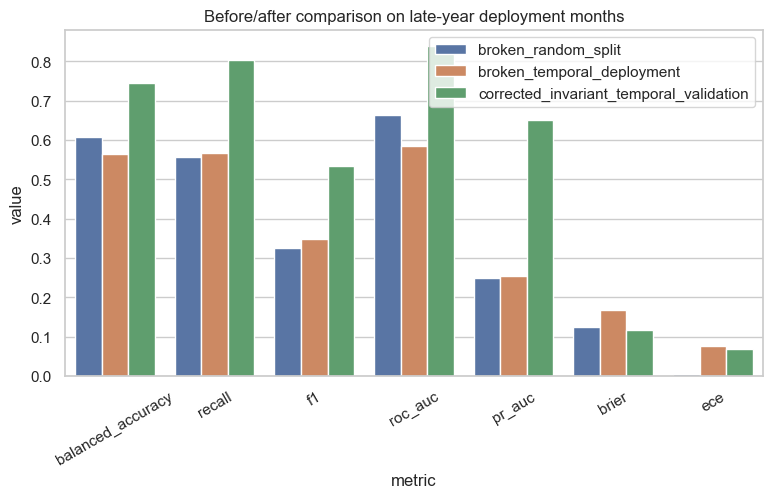

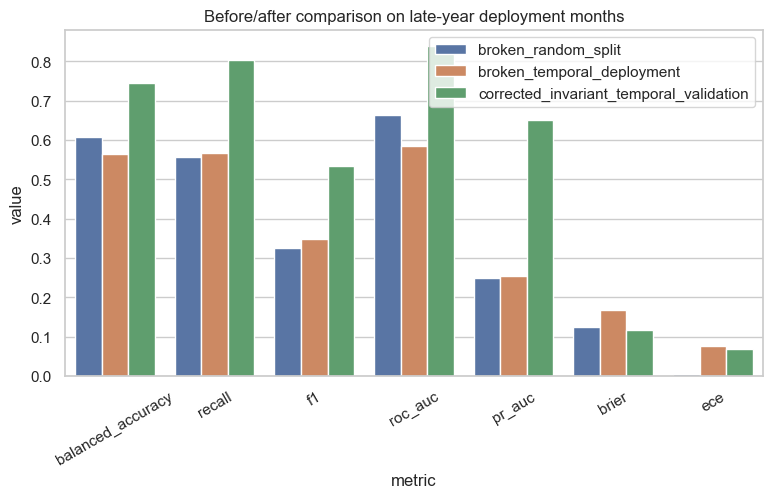

In [11]:
df = load_online_shoppers()
random_broken, broken = run_reference_and_failure(df, seed=RANDOM_SEED)
corrected = run_corrected_protocol(df, seed=RANDOM_SEED)
comparison = pd.DataFrame([
    metric_row(random_broken['name'], random_broken['y_test'], random_broken['proba'], random_broken['threshold']),
    metric_row(broken['name'], broken['y_test'], broken['proba'], broken['threshold']),
    metric_row(corrected['name'], corrected['y_test'], corrected['proba'], corrected['threshold']),
])
display(comparison.round(4))
write_metrics('table07_failure_evidence_summary.csv', comparison)
plot_metric_comparison(comparison, 'fig05_before_after_metrics.svg')


## Report-ready quantitative claims

These statements are generated from the actual run and can be copied into the report. They explicitly quantify PR-AUC drop, recall degradation, calibration shift, and after-correction performance.


In [12]:
claims = quantitative_claims(random_broken, broken, corrected)
display(claims)
with open(PROJECT_ROOT / 'report' / 'quantitative_claims.md', 'w', encoding='utf-8') as f:
    for claim in claims['claim']:
        f.write(f'- {claim}\n')


,claim
0,PR-AUC changed from 0.249 under random validat...
1,"After correction, PR-AUC was 0.652 on the same..."
2,purchase recall changed from 0.558 under rando...
3,"After correction, purchase recall was 0.803 on..."
4,balanced accuracy changed from 0.607 under ran...
5,"After correction, balanced accuracy was 0.745 ..."
6,expected calibration error changed from 0.005 ...
7,"After correction, expected calibration error w..."


## Failure Evidence Table with bootstrap confidence intervals

This is the central quantitative table for the final report. It combines random split, forced temporal failure, and corrected model with 95% bootstrap confidence intervals.


,model,metric,estimate,ci_low,ci_high,threshold,n,n_boot
0,broken_random_split,pr_auc,0.2492,0.2205,0.2938,0.1525,2466,500
1,broken_random_split,recall,0.5576,0.5063,0.6068,0.1525,2466,500
2,broken_random_split,balanced_accuracy,0.6068,0.5801,0.6348,0.1525,2466,500
3,broken_random_split,ece,0.0053,0.0036,0.0223,0.1525,2466,500
4,broken_random_split,brier,0.1257,0.1172,0.1344,0.1525,2466,500
5,broken_temporal_deployment,pr_auc,0.2544,0.2373,0.2748,0.1230,5274,500
6,broken_temporal_deployment,recall,0.5665,0.5403,0.5968,0.1230,5274,500
7,broken_temporal_deployment,balanced_accuracy,0.5645,0.5508,0.5817,0.1230,5274,500
8,broken_temporal_deployment,ece,0.0755,0.0655,0.0856,0.1230,5274,500
9,broken_temporal_deployment,brier,0.1679,0.1609,0.1748,0.1230,5274,500


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table08_failure_evidence_bootstrap_ci.csv')

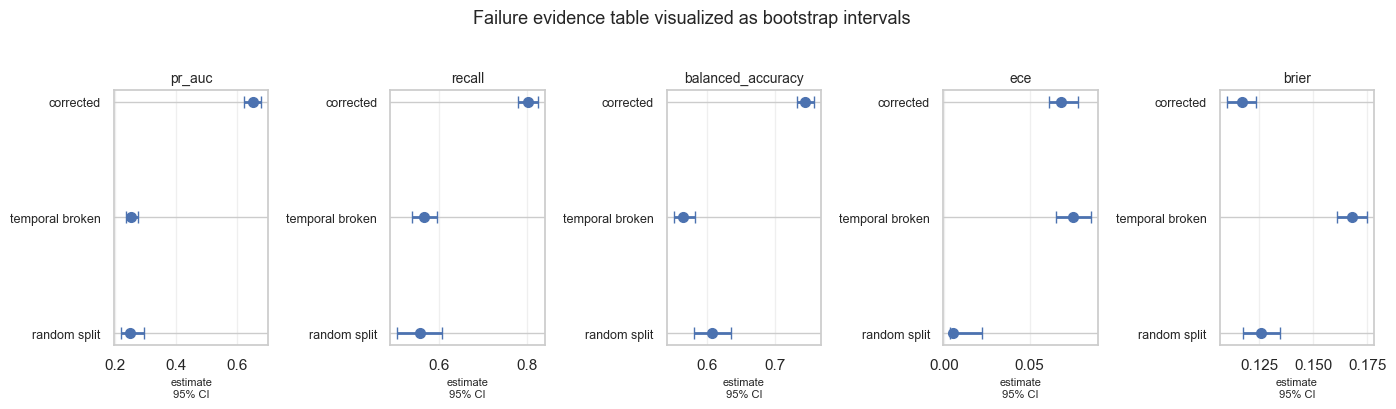

In [13]:
evidence = evidence_table([random_broken, broken, corrected], n_boot=500)
display(evidence.round(4))
plot_evidence_table(evidence, 'fig02_failure_evidence_bootstrap_ci.svg')
write_metrics('table08_failure_evidence_bootstrap_ci.csv', evidence)



## Bootstrap before/after effect sizes

The paired bootstrap estimates the improvement of the corrected model over the broken temporal model on the same Oct-Dec examples.


In [14]:
delta_rows = []
for metric in ['pr_auc', 'recall', 'balanced_accuracy', 'ece', 'brier']:
    delta_rows.append(paired_bootstrap_delta(
        broken['y_test'], broken['proba'], broken['threshold'], corrected['proba'], corrected['threshold'], metric, n_boot=500
    ))
before_after_delta = pd.DataFrame(delta_rows)
display(before_after_delta.round(4))
write_metrics('table09_before_after_bootstrap_deltas.csv', before_after_delta)


,metric,delta_after_minus_before,ci_low,ci_high,n_boot
0,pr_auc,0.3972,0.3631,0.4255,500
1,recall,0.2365,0.1992,0.2711,500
2,balanced_accuracy,0.1809,0.1583,0.1997,500
3,ece,-0.0071,-0.0227,0.0086,500
4,brier,-0.0511,-0.0588,-0.0431,500


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table09_before_after_bootstrap_deltas.csv')

## Confusion matrices and subgroup recovery

The repair should be visible not only in averaged metrics but also in purchase detection and month-level subgroup behavior.


,model,group,n,prevalence,recall,precision,f1,balanced_accuracy,roc_auc,pr_auc
0,before,Dec,1727,0.1251,0.6667,0.1716,0.2730,0.6034,0.6432,0.2061
1,before,Nov,2998,0.2535,0.5474,0.3054,0.3921,0.5623,0.5825,0.3028
2,before,Oct,549,0.2095,0.5043,0.2348,0.3204,0.5344,0.5532,0.2278
3,after,Dec,1727,0.1251,0.8796,0.2960,0.4429,0.7902,0.9060,0.7198
4,after,Nov,2998,0.2535,0.7579,0.4788,0.5869,0.7389,0.8183,0.6550
5,after,Oct,549,0.2095,0.9565,0.3264,0.4867,0.7167,0.8888,0.6862


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table10_subgroup_month_before_after.csv')

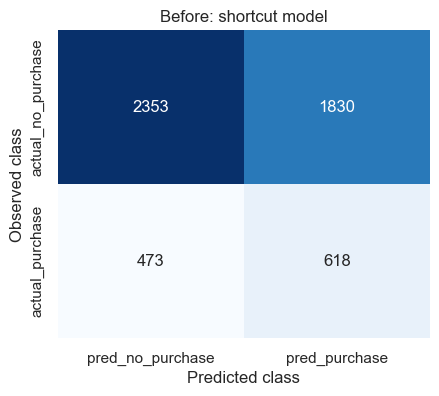

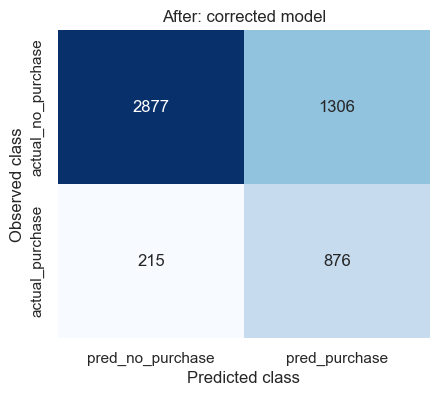

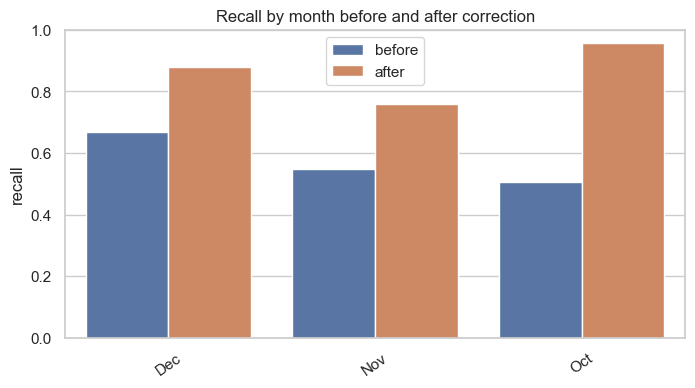

In [15]:
plot_confusion(broken['y_test'], broken['proba'], broken['threshold'], 'Before: shortcut model', 'fig01c_confusion_before_correction.svg')
plot_confusion(corrected['y_test'], corrected['proba'], corrected['threshold'], 'After: corrected model', 'fig01d_confusion_after_correction.svg')
month_before = subgroup_metrics(broken['test_frame'], broken['proba'], broken['threshold'], 'Month', 'before')
month_after = subgroup_metrics(corrected['test_frame'], corrected['proba'], corrected['threshold'], 'Month', 'after')
month_compare = pd.concat([month_before, month_after], ignore_index=True)
display(month_compare.round(4))
plot_subgroup(month_compare, 'recall', 'Recall by month before and after correction', 'fig07_subgroup_recall_by_month.svg')
write_metrics('table10_subgroup_month_before_after.csv', month_compare)


## Calibration under temporal shift

A deployable classifier needs probability estimates, not only rankings. The calibration curve checks whether predicted purchase probabilities align with observed purchase rates under the late-year regime.


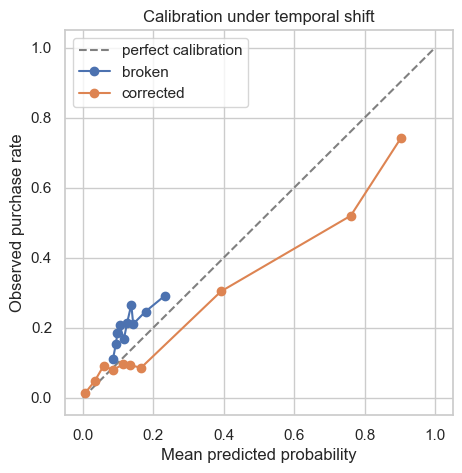

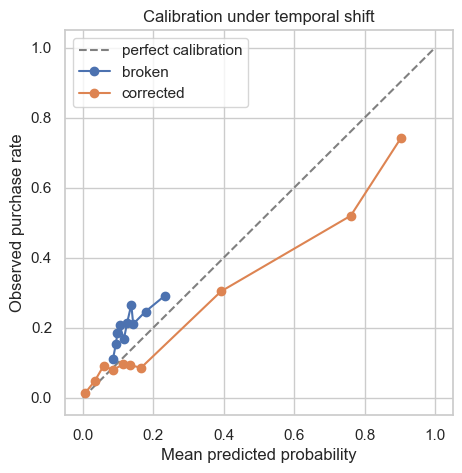

In [16]:
plot_calibration(corrected['y_test'], {'broken': broken['proba'], 'corrected': corrected['proba']}, 'fig08_calibration_before_after.svg')


## Variance analysis over fixed seeds

A single favorable seed is not evidence. The table below repeats the broken and corrected protocols and summarizes mean and standard deviation.


In [17]:
seed_runs = run_seed_variance(df)
display(seed_runs.round(4))
seed_summary = summarize_runs(seed_runs)
display(seed_summary)
write_metrics('table11_seed_variance_runs.csv', seed_runs)


,model,n,prevalence,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier,ece
0,broken_shortcut,5274,0.2069,0.1230,0.5622,0.5651,0.2526,0.5701,0.3501,0.5829,0.2559,0.1679,0.0756
1,corrected_invariant,5274,0.2069,0.1426,0.7217,0.7486,0.4107,0.7947,0.5415,0.8363,0.6515,0.1171,0.0717
2,broken_shortcut,5274,0.2069,0.1230,0.5645,0.5662,0.2537,0.5692,0.3509,0.5841,0.2530,0.1679,0.0752
3,corrected_invariant,5274,0.2069,0.1279,0.7019,0.7423,0.3932,0.8112,0.5296,0.8394,0.6516,0.1171,0.0665
4,broken_shortcut,5274,0.2069,0.1230,0.5616,0.5641,0.2519,0.5683,0.3491,0.5842,0.2542,0.1680,0.0763
5,corrected_invariant,5274,0.2069,0.1279,0.7078,0.7403,0.3971,0.7956,0.5298,0.8388,0.6503,0.1170,0.0657
6,broken_shortcut,5274,0.2069,0.1279,0.5794,0.5665,0.2566,0.5445,0.3488,0.5840,0.2549,0.1678,0.0748
7,corrected_invariant,5274,0.2069,0.1377,0.7110,0.7409,0.3998,0.7919,0.5314,0.8378,0.6518,0.1171,0.0695
8,broken_shortcut,5274,0.2069,0.1230,0.5637,0.5651,0.2529,0.5674,0.3498,0.5824,0.2530,0.1682,0.0764
9,corrected_invariant,5274,0.2069,0.1279,0.6959,0.7344,0.3865,0.8002,0.5212,0.8372,0.6519,0.1173,0.0678


balanced_accuracy          recall              f1          \
                                 mean     std    mean     std    mean     std   
model                                                                           
broken_shortcut                0.5654  0.0010  0.5639  0.0109  0.3498  0.0009   
corrected_invariant            0.7413  0.0051  0.7987  0.0076  0.5307  0.0073   

                    roc_auc          pr_auc           brier             ece  \
                       mean     std    mean     std    mean     std    mean   
model                                                                         
broken_shortcut      0.5835  0.0008  0.2542  0.0013  0.1680  0.0001  0.0757   
corrected_invariant  0.8379  0.0013  0.6514  0.0006  0.1171  0.0001  0.0682   

                             
                        std  
model                        
broken_shortcut      0.0007  
corrected_invariant  0.0024

WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table11_seed_variance_runs.csv')

## Bonus second failure mode: class imbalance hiding purchase failure

Symptom: because purchases are rare, a default threshold can yield attractive accuracy while purchase recall is weak.

Hypothesis: the default decision threshold optimizes majority-class behavior more than purchase detection.

Controlled test: keep the corrected model and probabilities fixed; manipulate only the threshold rule.

Correction: choose a threshold on validation data with an explicit recall objective subject to a minimum precision constraint. This is complementary to the main fix: representation repair addresses shortcut learning; threshold repair addresses decision asymmetry.


In [18]:
default = metric_row('corrected_default_0_50', corrected['y_test'], corrected['proba'], 0.50)
tuned = metric_row('corrected_cost_aware_threshold', corrected['y_test'], corrected['proba'], corrected['threshold'])
imbalance_table = pd.DataFrame([default, tuned])
display(imbalance_table.round(4))
imbalance_delta = []
for metric in ['accuracy', 'recall', 'precision', 'f1', 'balanced_accuracy']:
    imbalance_delta.append(paired_bootstrap_delta(
        corrected['y_test'], corrected['proba'], 0.50, corrected['proba'], corrected['threshold'], metric, n_boot=500
    ))
imbalance_delta = pd.DataFrame(imbalance_delta)
display(imbalance_delta.round(4))
write_metrics('table12_bonus_threshold_failure.csv', imbalance_table)
write_metrics('table13_bonus_threshold_bootstrap_deltas.csv', imbalance_delta)


,model,n,prevalence,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier,ece
0,corrected_default_0_50,5274,0.2069,0.5000,0.8491,0.8012,0.6157,0.7195,0.6636,0.8389,0.6516,0.1168,0.0684
1,corrected_cost_aware_threshold,5274,0.2069,0.1426,0.7116,0.7454,0.4015,0.8029,0.5353,0.8389,0.6516,0.1168,0.0684


,metric,delta_after_minus_before,ci_low,ci_high,n_boot
0,accuracy,-0.1375,-0.1477,-0.1269,500
1,recall,0.0834,0.0677,0.1017,500
2,precision,-0.2142,-0.2306,-0.1957,500
3,f1,-0.1283,-0.1430,-0.1124,500
4,balanced_accuracy,-0.0558,-0.0659,-0.0452,500


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table13_bonus_threshold_bootstrap_deltas.csv')

## Expanded threats to validity

- **Observational-data limitation.** The experiment manipulates model inputs and validation regimes, not user behavior. The causal claim concerns the prediction function.
- **Coarse temporal axis.** Month is not a true timestamp and the dataset is not a multi-year deployment log. Oct-Dec is a stress test, not a full production replay.
- **Confounding between seasonality and business campaigns.** Month, TrafficType, and VisitorType may reflect promotions or acquisition changes. The project treats them as unstable proxies, not as inherently invalid variables.
- **Leakage risk.** PageValues may encode information accumulated during the same session. The no-PageValues sensitivity analysis checks whether the correction depends entirely on this potentially leaky feature.
- **Threshold dependence.** The cost-aware threshold reflects an explicit business preference for purchase recall at minimum precision. Different costs would lead to a different threshold.
- **Statistical uncertainty.** Bootstrap intervals and seed variance reduce, but do not eliminate, uncertainty. Some month subgroups remain small.
- **External validity.** The conclusions should be retested on newer traffic logs before deployment.
- **Model-family dependence.** A neural network or gradient boosting model could exhibit a different shortcut profile. The project demonstrates a failure mechanism, not a universal theorem.


## Final conclusion

The final system is not claimed to be perfect. The stronger claim is scientific: the project intentionally induced a realistic failure, diagnosed why it occurred, repaired the identified mechanism, and quantified uncertainty. That is precisely the operational ML skill the assignment is designed to evaluate.
